In [1]:
import numpy as np
from matplotlib import pyplot as plt
from collections import Counter
import pickle

from qiskit_qaoa.utils.gfa_utils import gfa_file_to_graph
from qiskit_qaoa.hubo.graph_to_hubo_hamiltonian import graph_to_hubo_hamiltonian
from qiskit_qaoa.utils.string_utils import evaluate_sparse_pauli_samples

In [2]:
filename = 'test_N4_W5'
copy_numbers = [2,1,1,1]

In [3]:
filepath = f'/nfs/users/nfs_j/jc59/quantumwork/pangenome/data/{filename}.gfa'
graph, n, V, T = gfa_file_to_graph(filepath, copy_numbers)
num_qubits = n * T

full_hamiltonian = graph_to_hubo_hamiltonian(graph, n, T, lamda=10, constraint_terms=1.0)

keys = [np.binary_repr(x, num_qubits) for x in range(2**num_qubits)]
evals = evaluate_sparse_pauli_samples(keys, full_hamiltonian)

Keeping constraints at times: [1 2 0 3]


In [8]:
p = 1
with open(f'/lustre/scratch127/qpg/jc59/out/qiskit/hubo_no_shot_noise_optimum/sweep.{filename}.p{p}.pkl', 'rb') as f:
    res = pickle.load(f)

In [9]:
optimal_amplitudes = [r.fun for r in res['results']]
print(np.argmin(optimal_amplitudes))
res['results'][np.argmin(optimal_amplitudes)]

584


 message: Optimization terminated successfully.
 success: True
  status: 1
     fun: -3.528726365144405e-05
       x: [ 5.982e-01  1.552e-01]
    nfev: 36
   maxcv: 0.0

In [14]:
res['history'][0]

(np.float64(23.30291106500988),
 np.float64(-1.801190256773862e-06),
 [0.01, 0.01])

In [17]:
for idx, x in enumerate(res['history']):
    if np.allclose(x[2], [ 5.982e-01,  1.552e-01], atol=1e-6):
        print(idx)

27433
34064


In [18]:
res['history'][27433]

(np.float64(36.71330408647076),
 np.float64(-3.528726888132899e-05),
 [0.5982060444918896, 0.15520221980671595])

In [ ]:
sv = res['history'][27433][2]

In [20]:
sv = res['best_sv']

In [25]:
res['best_func_val'], res['best_params']

(np.float64(-3.5287275571605245e-05), array([0.59823433, 0.15517407]))

In [26]:
2 ** -20

9.5367431640625e-07

In [35]:
def plot_sv_bars(evals, sv):
    counter = Counter(evals)
    evals_set = list(set(evals))
    bars = {eval: 0 for eval in evals_set}
    for x in range(len(sv)):
        bars[evals[x]] += np.abs(sv[x]) ** 2
    sv_bars = np.array(list(bars.values()))

    _, ax = plt.subplots(1,1,figsize=(16, 5))
    labels = evals_set
    x = np.arange(len(labels))  # the label locations
    width = 0.35  # the width of the bars
    ax.bar(x - width/2, sv_bars, width, label='Statevector')
    ax.bar(x + width/2, np.array([counter[eval] for eval in sorted(evals_set)]) / 2**num_qubits, width, label='Random')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_yscale('log')
    ax.legend()

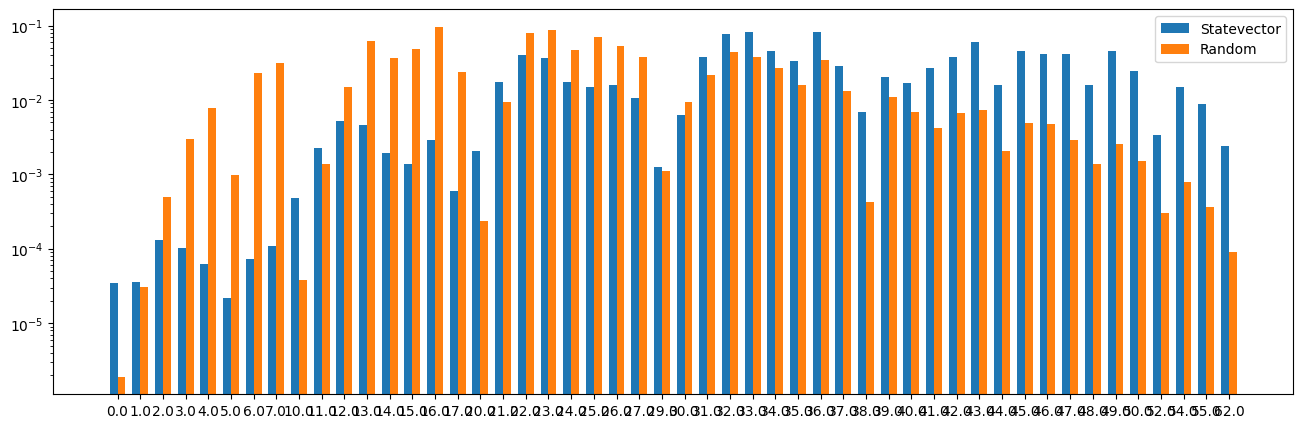

In [36]:
plot_sv_bars(evals, sv)

In [37]:
p = 2
with open(f'/lustre/scratch127/qpg/jc59/out/qiskit/hubo_no_shot_noise_optimum/sweep.{filename}.p{p}.pkl', 'rb') as f:
    res = pickle.load(f)

In [11]:
optimal_amplitudes = [r.fun for r in res['results']]
print(np.argmin(optimal_amplitudes))
res['results'][np.argmin(optimal_amplitudes)]

541


 message: Optimization terminated successfully.
 success: True
  status: 1
     fun: -0.2641686355784434
       x: [ 6.154e-01  2.996e-01  2.099e-01  3.791e-01]
    nfev: 67
   maxcv: 0.0

In [17]:
for idx, x in enumerate(res['history']):
    if np.allclose(x[1], [6.154e-01, 2.996e-01, 2.099e-01, 3.791e-01], atol=4e-5):
        print(idx)

44373
47525


In [20]:
res['history'][44373][1]

[0.615435523787901,
 0.2996057600097427,
 0.20990281059253305,
 0.37913465022920295]

In [21]:
sv = res['history'][44373][2]

In [38]:
sv = res['best_sv']

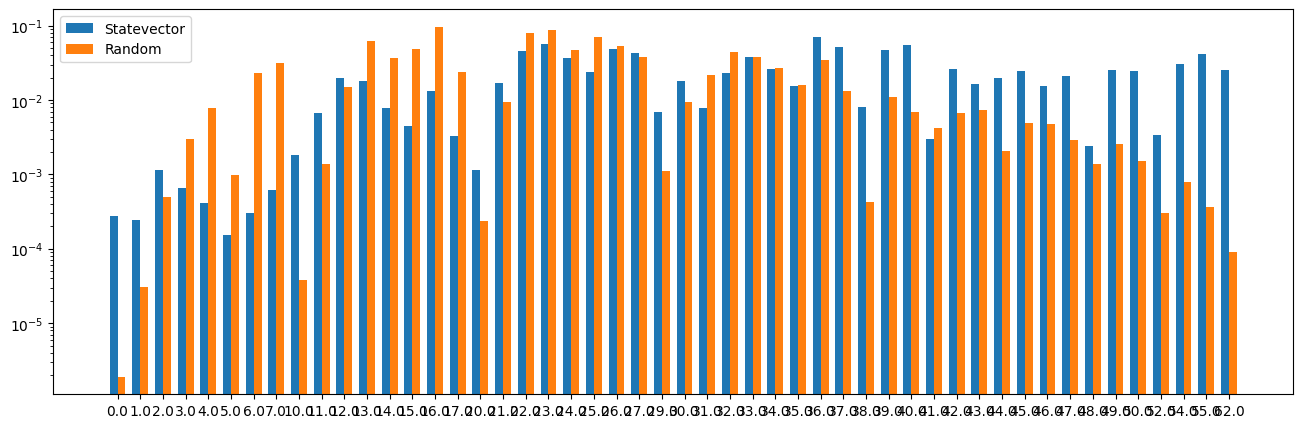

In [39]:
plot_sv_bars(evals, sv)

In [3]:
p = 3
with open(f'/lustre/scratch127/qpg/jc59/out/qiskit/hubo_no_shot_noise_optimum/single.{filename}.p{p}.pkl', 'rb') as f:
    res = pickle.load(f)

In [7]:
res['history'][0][1]

[0.6058, 0.3503, 0.3691, 0.1844, 0.9353, 0.9155]

In [4]:
sv = res['history'][0][2]

In [5]:
plot_sv_bars(evals, sv)

NameError: name 'plot_sv_bars' is not defined